In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn
import kind

data_dir = '../../../data/mujoco/hopper'
model_dir = '../../../models/mujoco/hopper'
result_dir = '../../../results/mujoco/hopper'

In [2]:
# --! use seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[0]

print(f'selecting seed {seed}')

selecting seed 3


In [3]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', data_dir,
        '--file_name', 'hopper',
        '--data_nsample_baseline', '918',
        '--data_nsample_nom', '48',
        '--data_nsample_exc', '48',
        '--obs_ndim', '11',
        '--act_ndim', '3',
        '--target_ndim', '11',
        '--data_train_size', '0.8',

        '--back_nsample', '32',
        '--fore_nsample', '16',

        '--batch_size', '256',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '500',
        '--patience', '50',
        '--checkpoints', model_dir,

        '--rez_nsample_nom', '16',
        '--rez_nsample_exc', '8',
        '--embed_nom', '{"sin": 6, "cos": 6}',
        '--embed_exc', '{"data": 12}',
    ]
)

# --! instantiate a KIND model
model = kind.model(args)

# --! load trained weights into the model
model_path = args.checkpoints + '/' + f'checkpoint_{seed}.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

setpoint = torch.zeros(args.target_ndim)

dataset = example_mujoco.dataset(args, setpoint, load_normalized=False, extract_windows=False)
model = kind.model_adapter(model, dataset.normalizer)

read evaluation data shape: torch.Size([30, 918, 14])


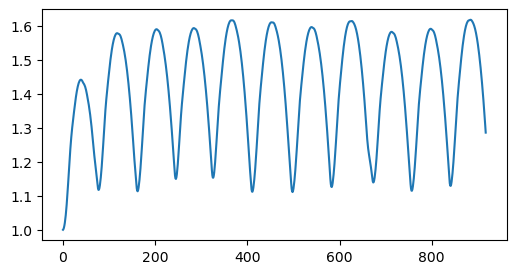

In [4]:
# --! load evaluation data

eval_data = util_data.read_datafile(f'{data_dir}/eval', args.data_nsample_baseline)
print(f'read evaluation data shape: {eval_data.shape}')

plt.figure(figsize=(6,3))
plt.plot(eval_data[0, :, 0])
plt.show()


In [18]:
# --! perform model rollout --!

offset = 0
horizon = 800 # rollout length, horizon
reanchor_nsample = 1_000_000 # re-anchor after this number of samples

jdata = 10

true, next_ss, alphas, zetas_nom, zetas_exc, means_nom, means_exc = example_mujoco.rollout_kind(
    model,
    eval_data[[jdata]],
    horizon=horizon, reset_nsample=reanchor_nsample, offset=offset)

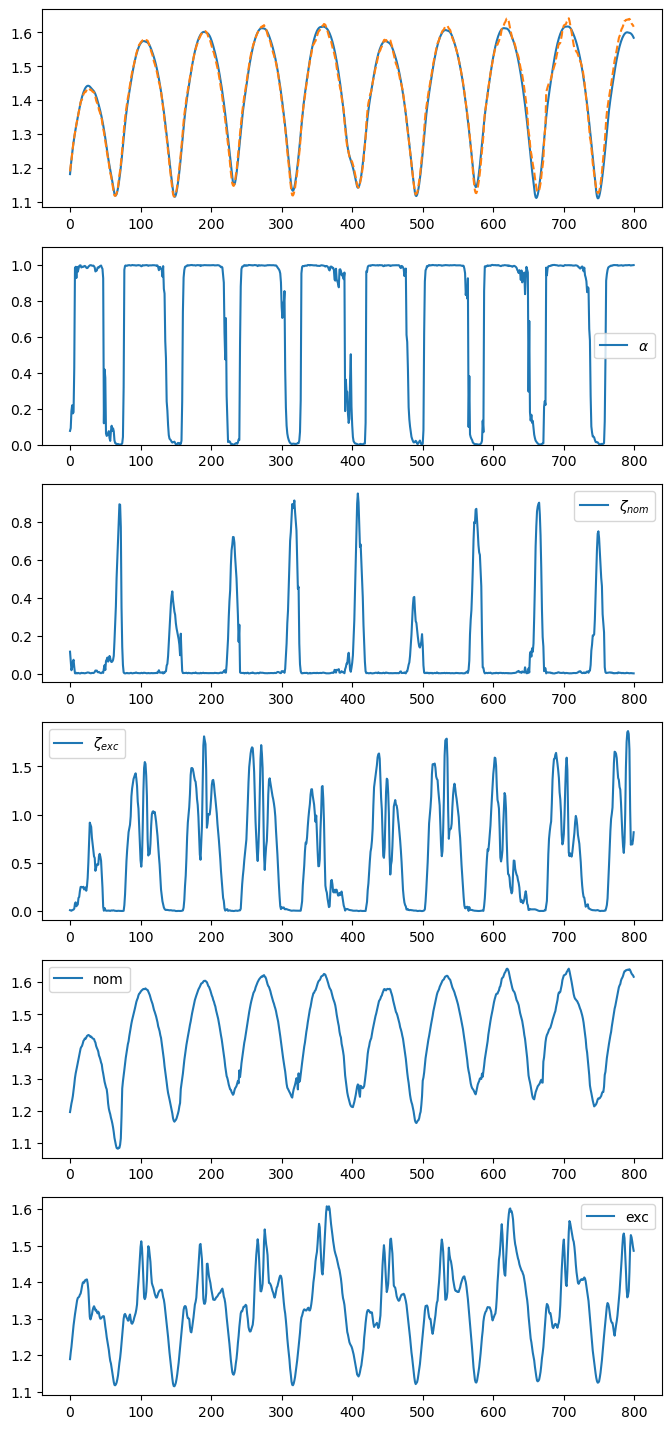

In [19]:
# --! plot rollout

with torch.no_grad():
    plt.figure(figsize=(8,18))

    plt.subplot(6,1,1)
    plt.plot(true[0, :, 0])
    plt.plot(next_ss[0, :, 0], linestyle='dashed')

    plt.subplot(6,1,2)
    plt.plot(alphas[0, :, 0], label='$\\alpha$')
    plt.ylim((0.0, 1.1))
    plt.legend()

    plt.subplot(6,1,3)
    plt.plot(zetas_nom[0, :, 0], label='$\\zeta_{nom}$')
    plt.legend()

    plt.subplot(6,1,4)
    plt.plot(zetas_exc[0, :, 0], label='$\\zeta_{exc}$')
    plt.legend()

    plt.subplot(6,1,5)
    plt.plot(means_nom[0, :, 0], label='nom')
    plt.legend()

    plt.subplot(6,1,6)
    plt.plot(means_exc[0, :, 0], label='exc')
    plt.legend()

    plt.show()

## Save rollout data

In [21]:
datasaved = False

if datasaved:
    reanchor_string = 'none' if reanchor_nsample > h else f'{reanchor_nsample}'
    step = torch.arange(true.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        step,
        true[..., :1], next_ss[..., :1],
        alphas[..., :1], zetas_nom[..., :1], zetas_exc[..., :1],
        means_nom[..., :1], means_exc[..., :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/kind_rollout_reanchor_{reanchor_string}_seed_{seed}', savedata, delim=' ')

### Analyzing MSE vs. horizon

In [8]:
# --! compute mse vs. horizon
mseanalyzed = True

assert horizon <= eval_data.shape[1] - args.back_nsample

if mseanalyzed:
    traj_mse = []
    with torch.no_grad():
        for j in range(eval_data.shape[0]): # trajectory
            print(f'processing trajectory {j+1} out of {eval_data.shape[0]}')
            mse = []
            for h in range(1, horizon + 1): # horizon
                traj_true = eval_data[[j]]
                rollout_o = example_mujoco.rollout_kind(model, traj_true, horizon=h, reset_nsample=reanchor_nsample)
                true = rollout_o[0]
                next_ss = rollout_o[1]
                true_obs = true[..., :args.obs_ndim]

                loss = F.mse_loss(next_ss, true_obs)
                mse.append(loss)
                if h % 100 == 0:
                    print(f'\thorizon {h} out of {horizon}, loss: {loss}')
            mse = torch.stack(mse)
            traj_mse.append(mse)
        traj_mse = torch.stack(traj_mse)


processing trajectory 1 out of 30
	horizon 100 out of 800, loss: 0.07536768913269043
	horizon 200 out of 800, loss: 0.09303529560565948
	horizon 300 out of 800, loss: 0.12749914824962616
	horizon 400 out of 800, loss: 0.28570684790611267
	horizon 500 out of 800, loss: 0.2669742703437805
	horizon 600 out of 800, loss: 0.358894944190979
	horizon 700 out of 800, loss: 0.34045490622520447
	horizon 800 out of 800, loss: 0.3762965202331543
processing trajectory 2 out of 30
	horizon 100 out of 800, loss: 0.09434331208467484
	horizon 200 out of 800, loss: 0.07993942499160767
	horizon 300 out of 800, loss: 0.10016821324825287
	horizon 400 out of 800, loss: 0.10443680733442307
	horizon 500 out of 800, loss: 0.09928689897060394
	horizon 600 out of 800, loss: 0.1313549131155014
	horizon 700 out of 800, loss: 0.1599954068660736
	horizon 800 out of 800, loss: 0.17316123843193054
processing trajectory 3 out of 30
	horizon 100 out of 800, loss: 0.060965459793806076
	horizon 200 out of 800, loss: 0.096

tensor(0.0251)
tensor(0.0414)


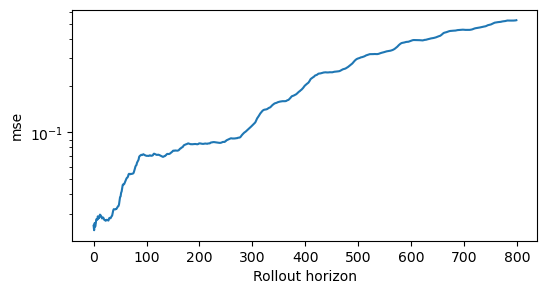

In [9]:
# --! plot MSE vs. horizon

traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.xlabel('Rollout horizon')
    plt.ylabel('mse')
    plt.show()

datasaved = True
if datasaved:
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/kind_mse_seed_{seed}', savedata, delim=' ')

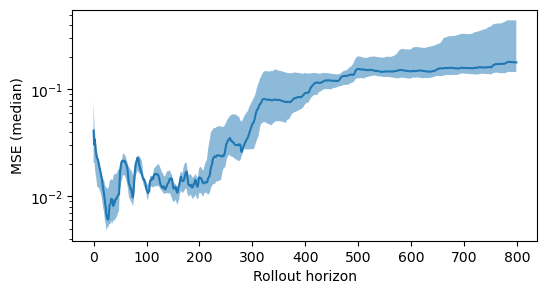

In [13]:
mseprocessed = False

if mseprocessed:
    length = 800
    mse_data = [
        util_data.read_datafile(
            f'{result_dir}/kind_mse_seed_{s}', length, delim=' ') for s in seeds]
    mse = torch.cat([mse[..., [2]] for mse in mse_data], dim=0)
    mse_median, _ = torch.median(mse, dim=0, keepdim=True)
    mse_percentile_10 = torch.quantile(mse, 0.1, dim=0, keepdim=True)
    mse_percentile_90 = torch.quantile(mse, 0.9, dim=0, keepdim=True)

    x = torch.arange(mse_median.shape[1]).reshape(1, -1, 1)

    plt.figure(figsize=(6,3))
    plt.plot(x[0, :, 0], mse_median[0, :, 0], linestyle='solid')
    plt.fill_between(x[0, :, 0], mse_percentile_10[0, :, 0], mse_percentile_90[0, :, 0], alpha=0.5)
    plt.yscale('log')
    plt.xlabel('Rollout horizon')
    plt.ylabel('MSE (median)')
    plt.show()

    horizon = length
    nmse = mse.shape[0]
    save_step = torch.arange(mse_median.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :horizon, :1],
        mse_median[:1, :horizon, :1],
        mse_percentile_10[:1, :horizon, :1], mse_percentile_90[:1, :horizon, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/kind_mse_avg_{nmse}', savedata, delim=' ')